# Ground separation: see, compare, and iterate

**AI4Infra Hackathon Fall 2026**

Use this notebook to inspect what our baseline and CSF ground filters keep or remove. It opens with real saved results from this workspace. [inspect_las.ipynb](inspect_las.ipynb) remains our metadata and statistics notebook.

**Start here:** in VS Code choose **Select Kernel > Python Environments > .venv-ground** (`.venv-ground/Scripts/python.exe`), or the kernel named **LiDAR Ground Experiments (.venv-ground)**. Then run from the top. The plotting and notebook dependencies are installed in that local environment; [requirements-ground-notebook.txt](requirements-ground-notebook.txt) records them.

The first stages **load saved results**. New filtering happens only in the clearly marked experiment cell near the end, with `RUN_NEW_EXPERIMENT = False` by default. Raw LAS files, the inspection notebook, baseline outputs, and earlier experiments are preserved. New runs use unique folders.

We do not have a recorded missing-road location or labeled accuracy measurements. The initial region is a populated example chosen from the cached sample, not a claim about where the road disappeared. Choose your investigation region using the overview below.

## 1. Select the input

Left and right are separate scans with different sample records. Choose one side for a fair method comparison; we have not established that the scans are aligned well enough to merge.

The walkthrough imports short helper calls. Filtering still uses `ground_mask()` and `csf_ground_mask()` from [sample_and_ground.py](sample_and_ground.py). Data loading, matching, and recording are in [ground_experiment_tools.py](ground_experiment_tools.py); drawing code is in [ground_experiment_views.py](ground_experiment_views.py). Open those files when you want to inspect the implementation.

In [1]:
from pathlib import Path
import sys
import numpy as np
from IPython.display import display

PROJECT_DIR = Path.cwd().resolve()  # Change this if the kernel starts in another folder.
if not (PROJECT_DIR / "ground_experiment_tools.py").is_file():
    raise FileNotFoundError("Set PROJECT_DIR to the folder containing this notebook.")
sys.path.insert(0, str(PROJECT_DIR))
import ground_experiment_tools as data
import ground_experiment_views as view
%matplotlib inline
print("Kernel:", sys.executable)

Kernel: C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\.venv-ground\Scripts\python.exe


In [2]:
INPUT_SIDE = "left"  # "left" or "right"; no automatic merging.
catalog = data.load_catalog(PROJECT_DIR)
RESULT_COLUMNS = ["name", "input_sample", "input_points", "ground_points", "non_ground_points",
                  "parameters", "runtime_seconds", "runtime_scope", "processing_context", "observations"]
view.show_table(catalog["rows"], columns=["saved_run", "side", "sample_points_manifest",
    "ground_points_header", "non_ground_points_header", "parameters_coordinate_units", "sample_lineage", "sample_link"])
if catalog["errors"]:
    print("Missing/unreadable files:", "\n".join(catalog["errors"]))

saved_run,side,sample_points_manifest,ground_points_header,non_ground_points_header,parameters_coordinate_units,sample_lineage,sample_link
Baseline (saved),left,"1,997,914","1,651,756","346,158","{ ""cell_size"": 1.0, ""tolerance"": 0.35 }{ ""cell_size"": 1.0, ""tolerance"": 0.35 }",same manifest settings; regional record check still required,present
Baseline (saved),right,"1,996,690","1,631,519","365,171","{ ""cell_size"": 1.0, ""tolerance"": 0.35 }{ ""cell_size"": 1.0, ""tolerance"": 0.35 }",same manifest settings; regional record check still required,present
CSF previous (saved),left,"1,997,914","1,137,149","860,765","{ ""cloth_resolution"": 2.0, ""class_threshold"": 0.5, ""rigidness"": 2, ""time_step"": 0.65, ""…{ ""cloth_resolution"": 2.0, ""class_threshold"": 0.5, ""rigidness"": 2, ""time_step"": 0.65, ""iterations"": 200, ""slope_smooth"": false }",same manifest settings; regional record check still required,stale/missing; cached sample checked when loading region
CSF previous (saved),right,"1,996,690","1,069,550","927,140","{ ""cloth_resolution"": 2.0, ""class_threshold"": 0.5, ""rigidness"": 2, ""time_step"": 0.65, ""…{ ""cloth_resolution"": 2.0, ""class_threshold"": 0.5, ""rigidness"": 2, ""time_step"": 0.65, ""iterations"": 200, ""slope_smooth"": false }",same manifest settings; regional record check still required,stale/missing; cached sample checked when loading region
CSF current (saved),left,"1,997,914","1,509,441","488,473","{ ""cloth_resolution"": 1.0, ""class_threshold"": 0.8, ""rigidness"": 3, ""time_step"": 0.65, ""…{ ""cloth_resolution"": 1.0, ""class_threshold"": 0.8, ""rigidness"": 3, ""time_step"": 0.65, ""iterations"": 500, ""slope_smooth"": true }",same manifest settings; regional record check still required,present
CSF current (saved),right,"1,996,690","1,486,630","510,060","{ ""cloth_resolution"": 1.0, ""class_threshold"": 0.8, ""rigidness"": 3, ""time_step"": 0.65, ""…{ ""cloth_resolution"": 1.0, ""class_threshold"": 0.8, ""rigidness"": 3, ""time_step"": 0.65, ""iterations"": 500, ""slope_smooth"": true }",same manifest settings; regional record check still required,present


### What is processing data, and what is display data?

| Data | Purpose in this notebook |
|---|---|
| Original raw LAS, about 112 million points per side | Provenance only; no raw point scan is performed. |
| `outputs/run1_inputs/run1_*_sample.las`, about 2 million per side | Actual processing source. We load all its points inside the selected region plus a margin. |
| Existing voxel previews | Not used for filtering or these comparisons. |
| Bounded point selections made by the plotting helpers | Display only. They never replace the processing input. |

**Units remain unresolved.** LAS headers declare US survey feet; sidecars say meters. Earlier manifests call this resolved and use `_m` names, but the scripts do not convert coordinates. Here, all distances and parameters use **source coordinate units** (called *cloud units* on plots). We subtract one common origin for readable axes; that is a translation, not a unit conversion.

Selected sample: C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\run1_inputs\run1_left_sample.las
Shared XYZ origin: [2453810.1308, 414035.2235, 725.821]


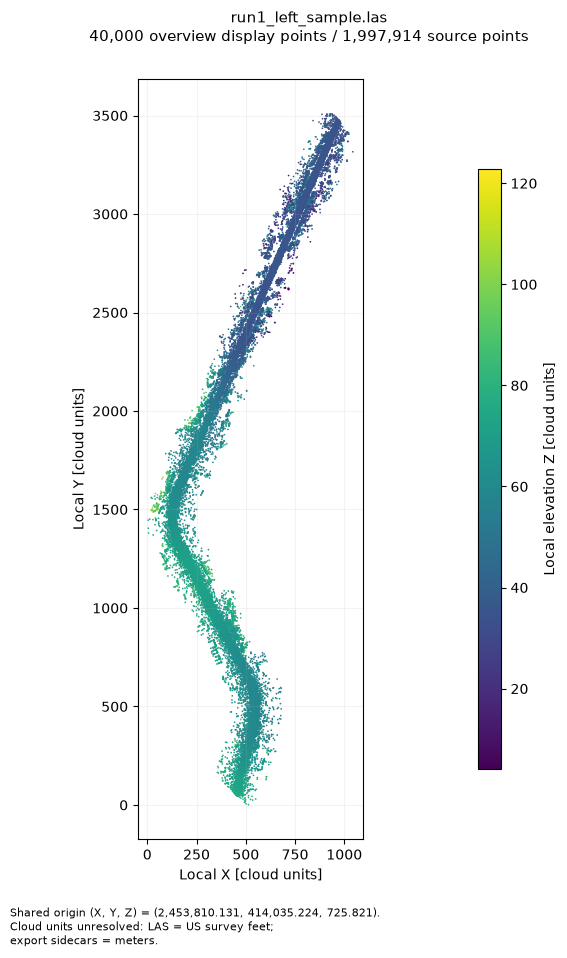

In [3]:
overview = data.load_overview(catalog, INPUT_SIDE, max_display_points=40_000)
print("Selected sample:", overview["source_path"])
print("Shared XYZ origin:", overview["origin"].tolist())
view.plot_overview(overview)

## 2. Select a manageable region

Read the **local X and local Y** axes on the overview. Enter the center of the area you want to inspect below. `ROI_SIZE` gives its width in X and Y. The red box shows the evaluation region. The starting center selects a populated example near the middle of the route.

`PROCESSING_MARGIN` adds surrounding points for new filters so the evaluation region is not directly at the crop boundary. It reduces one boundary concern but does not make a local CSF run equivalent to the saved whole-sample run. No Z limit is applied while loading, so elevated points remain available for examination.

If you change the side, region, or margin, rerun from this stage through the saved comparisons before computing. A point limit stops oversized local requests instead of silently thinning the processing cloud.

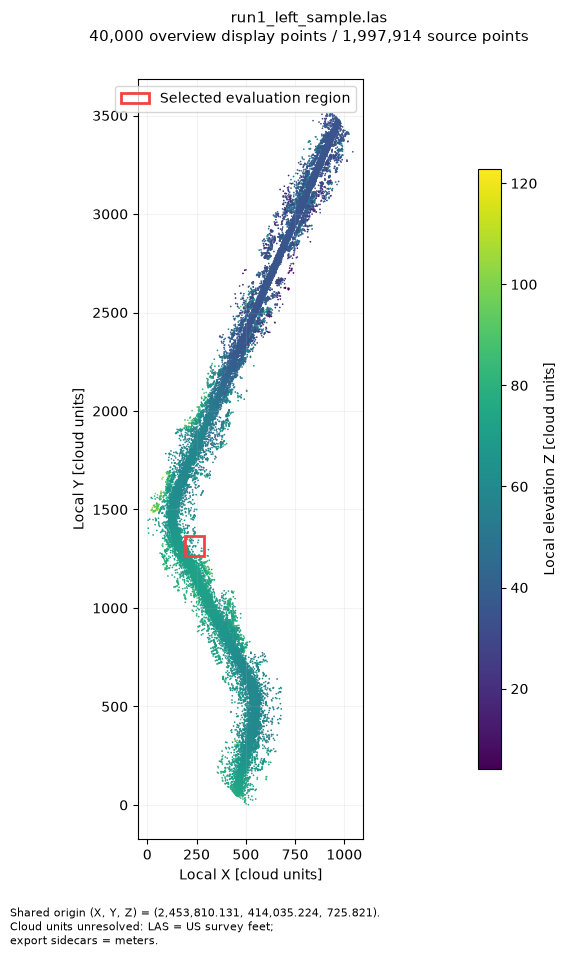

In [4]:
ROI_CENTER_LOCAL = (240.0, 1315.0)  # EDIT: local X, local Y; example, not missing-road location.
ROI_SIZE = (100.0, 100.0)           # EDIT: X width, Y width, in source coordinate units.
PROCESSING_MARGIN = 20.0           # Additional context on each side, same units.
MAX_PROCESSING_POINTS = 250_000

center = np.asarray(ROI_CENTER_LOCAL) + overview["origin"][:2]
half = np.asarray(ROI_SIZE) / 2
roi_xy = [center[0] - half[0], center[0] + half[0], center[1] - half[1], center[1] + half[1]]
view.plot_overview(overview, roi_xy=roi_xy)

In [5]:
region = data.load_region(catalog, INPUT_SIDE, roi_xy, padding=PROCESSING_MARGIN,
                         max_processing_points=MAX_PROCESSING_POINTS)
saved_results, new_run, previous_run = [], None, None  # Clear results from any earlier region.
print("Evaluation points:", int(region["evaluation_mask"].sum()))
print("Processing points, including margin:", len(region["records"]))
print("Absolute XY region:", region["roi_xy"])
print("Input fingerprint:", region["fingerprint"])

Evaluation points: 11609
Processing points, including margin: 45881
Absolute XY region: [2454000.1308, 2454100.1308, 415300.2235, 415400.2235]
Input fingerprint: 25df318b5d1085bb78ef3e0644aa370e2153d2bd0bacd4e969d3e44f95d6bb4a


## 3. View the region before filtering

The **top-down view** shows where points lie in XY. The **elevation cross-section** shows a narrow strip: with `SECTION_AXIS = "y"`, we select a band of local Y and plot X against elevation. Use `"x"` to select an X band and plot Y against elevation.

`SECTION_POSITION = None` centers the band in the region; enter a local coordinate to move it. Blue lines mark the band on top-down plots. Keep these settings fixed while comparing methods. Plot limits come from the entire evaluation input, and the same display point indices are used in corresponding method panels. Section points are selected **before** any display thinning.

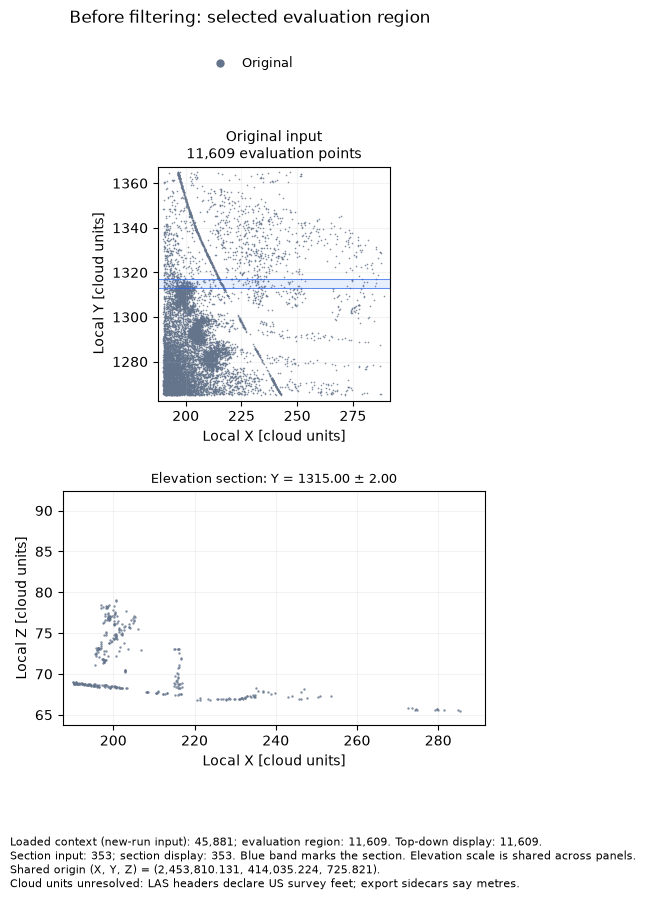

In [6]:
VIEW = dict(max_display_points=20_000, section_axis="y",
            section_position=None, section_width=4.0)
view.plot_region(region, **VIEW)

## 4. Load the baseline result

Our baseline divides XY into cells, finds the lowest Z in each cell, and calls points within a height tolerance of that minimum **ground candidates**. The saved baseline used a cell size of 1.0 and tolerance of 0.35 source coordinate units.

This simple rule can retain an object if that object supplies the lowest observed point in its cell. A steep surface can also rise beyond the tolerance within a cell. These are limitations of the rule, not proven explanations for a particular error in this scene.

The next cell **loads the saved partition**; it does not recompute it. The helper checks complete point records, including duplicates, against the selected sample and context. A mismatch stops the comparison. Ground candidates are **green**, non-ground points **orange**, and the original input **gray** throughout the comparison figures. No LAS semantic labels are assigned.

Exact full-record multiset match for every point in this region plus padding.


name,input_sample,input_points,ground_points,non_ground_points,parameters,runtime_seconds,runtime_scope,processing_context,observations
Baseline (saved),C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\run1_inputs\run1_left_sample.las,"11,609","7,890","3,719","{ ""cell_size"": 1.0, ""tolerance"": 0.35 }{ ""cell_size"": 1.0, ""tolerance"": 0.35 }",2.8842,"historical pipeline total for BOTH sides, including input/output work; not this ROI's filter time","entire historical development sample, then cropped for evaluation",


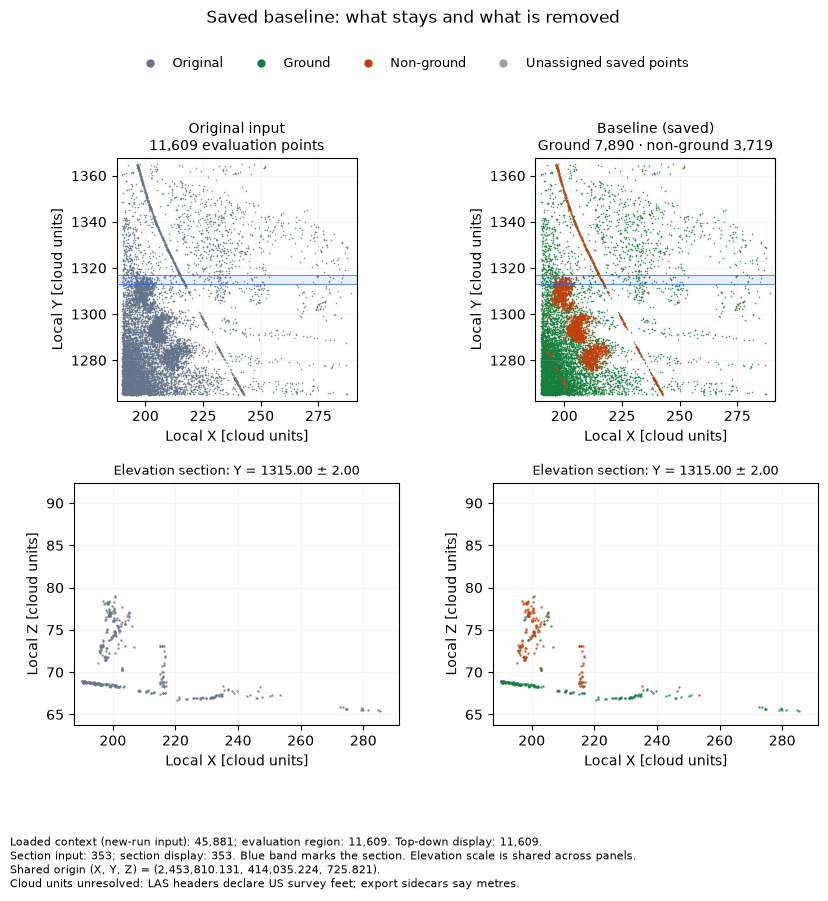

In [7]:
baseline = data.load_saved_result(catalog, region, "baseline")
print(baseline["source_note"])
view.show_table(data.comparison_rows(region, [baseline]), columns=RESULT_COLUMNS)
view.plot_comparison(region, [baseline], title="Saved baseline: what stays and what is removed", **VIEW)

## 5. Load the CSF result

Cloth Simulation Filter (CSF) estimates a terrain surface using a simulated cloth against an inverted point cloud, then separates points by their distance to that surface. It is an established ground-filtering method; its original airborne-data validation does not establish accuracy for our scene. See the [authors' implementation](https://github.com/jianboqi/CSF) and [Zhang et al. (2016)](https://doi.org/10.3390/rs8060501).

Our saved **current CSF** run used resolution 1.0, threshold 0.8, rigidness 3, 500 iterations, time step 0.65, and slope smoothing enabled. The older run used resolution 2.0, threshold 0.5, rigidness 2, 200 iterations, and no slope smoothing. We read those values from the manifests below.

As with the baseline, this stage **loads saved results**, checks that the selected point records match, and shows both sides of the partition. More green points do not by themselves mean greater accuracy.

Exact full-record multiset match for every point in this region plus padding.


name,input_sample,input_points,ground_points,non_ground_points,parameters,runtime_seconds,runtime_scope,processing_context,observations
CSF current (saved),C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\run1_inputs\run1_left_sample.las,"11,609","7,566","4,043","{ ""cloth_resolution"": 1.0, ""class_threshold"": 0.8, ""rigidness"": 3, ""time_step"": 0.65, ""…{ ""cloth_resolution"": 1.0, ""class_threshold"": 0.8, ""rigidness"": 3, ""time_step"": 0.65, ""iterations"": 500, ""slope_smooth"": true }",142.5113,"historical pipeline total for BOTH sides, including input/output work; not this ROI's filter time","entire historical development sample, then cropped for evaluation",


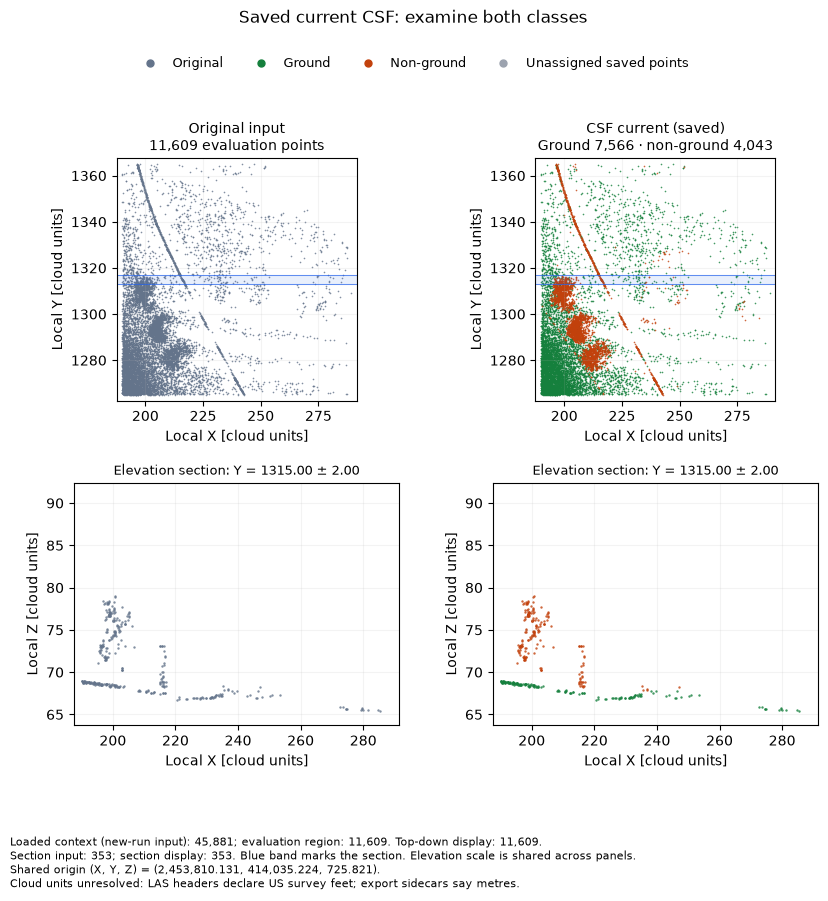

In [8]:
csf = data.load_saved_result(catalog, region, "csf_current")
print(csf["source_note"])
view.show_table(data.comparison_rows(region, [csf]), columns=RESULT_COLUMNS)
view.plot_comparison(region, [csf], title="Saved current CSF: examine both classes", **VIEW)

## 6. Compare original, baseline, and CSF directly

Compare a feature across columns using the same coordinate origin, axis limits, colors, and display samples. In the lower row, look for continuous low surfaces that move from green to orange. Until you identify and label reference road areas, this is a qualitative inspection rather than a road-retention accuracy measurement.

The original panel means the **unfiltered cached-sample region**, not all raw returns. The table counts every evaluation point even if a display cap is active.

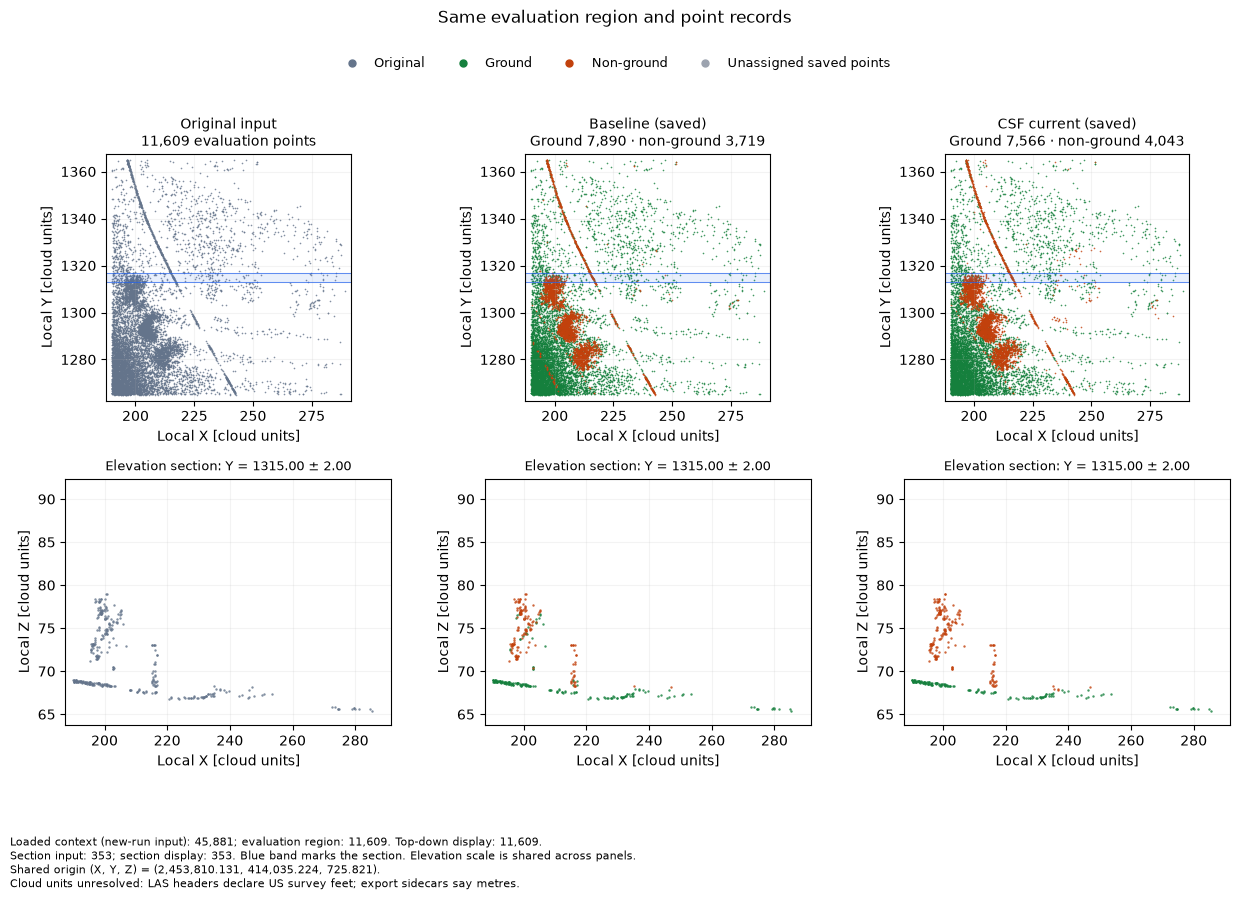

In [9]:
view.plot_comparison(region, [baseline, csf], title="Same evaluation region and point records", **VIEW)

### Compare the saved iterations

The archive and current CSF runs changed several settings together. This shows where their outputs differ, but cannot isolate which setting caused a difference. Their recorded runtimes cover the original paired left/right pipeline, not just this crop or just the filter kernel.

The archived manifest's sample links are stale. The notebook resolves the current cached sample and verifies exact point-record agreement in the selected context; it does not treat matching point counts alone as proof of shared input. This local verification does not establish full-file historical lineage.

Exact full-record multiset match for every point in this region plus padding. Historical sample link is stale; verified against the present cached sample.


name,input_sample,input_points,ground_points,non_ground_points,parameters,runtime_seconds,runtime_scope,processing_context,observations
Baseline (saved),C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\run1_inputs\run1_left_sample.las,"11,609","7,890","3,719","{ ""cell_size"": 1.0, ""tolerance"": 0.35 }{ ""cell_size"": 1.0, ""tolerance"": 0.35 }",2.8842,"historical pipeline total for BOTH sides, including input/output work; not this ROI's filter time","entire historical development sample, then cropped for evaluation",
CSF previous (saved),C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\run1_inputs\run1_left_sample.las,"11,609","7,055","4,554","{ ""cloth_resolution"": 2.0, ""class_threshold"": 0.5, ""rigidness"": 2, ""time_step"": 0.65, ""…{ ""cloth_resolution"": 2.0, ""class_threshold"": 0.5, ""rigidness"": 2, ""time_step"": 0.65, ""iterations"": 200, ""slope_smooth"": false }",15.4388,"historical pipeline total for BOTH sides, including input/output work; not this ROI's filter time","entire historical development sample, then cropped for evaluation",
CSF current (saved),C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\run1_inputs\run1_left_sample.las,"11,609","7,566","4,043","{ ""cloth_resolution"": 1.0, ""class_threshold"": 0.8, ""rigidness"": 3, ""time_step"": 0.65, ""…{ ""cloth_resolution"": 1.0, ""class_threshold"": 0.8, ""rigidness"": 3, ""time_step"": 0.65, ""iterations"": 500, ""slope_smooth"": true }",142.5113,"historical pipeline total for BOTH sides, including input/output work; not this ROI's filter time","entire historical development sample, then cropped for evaluation",


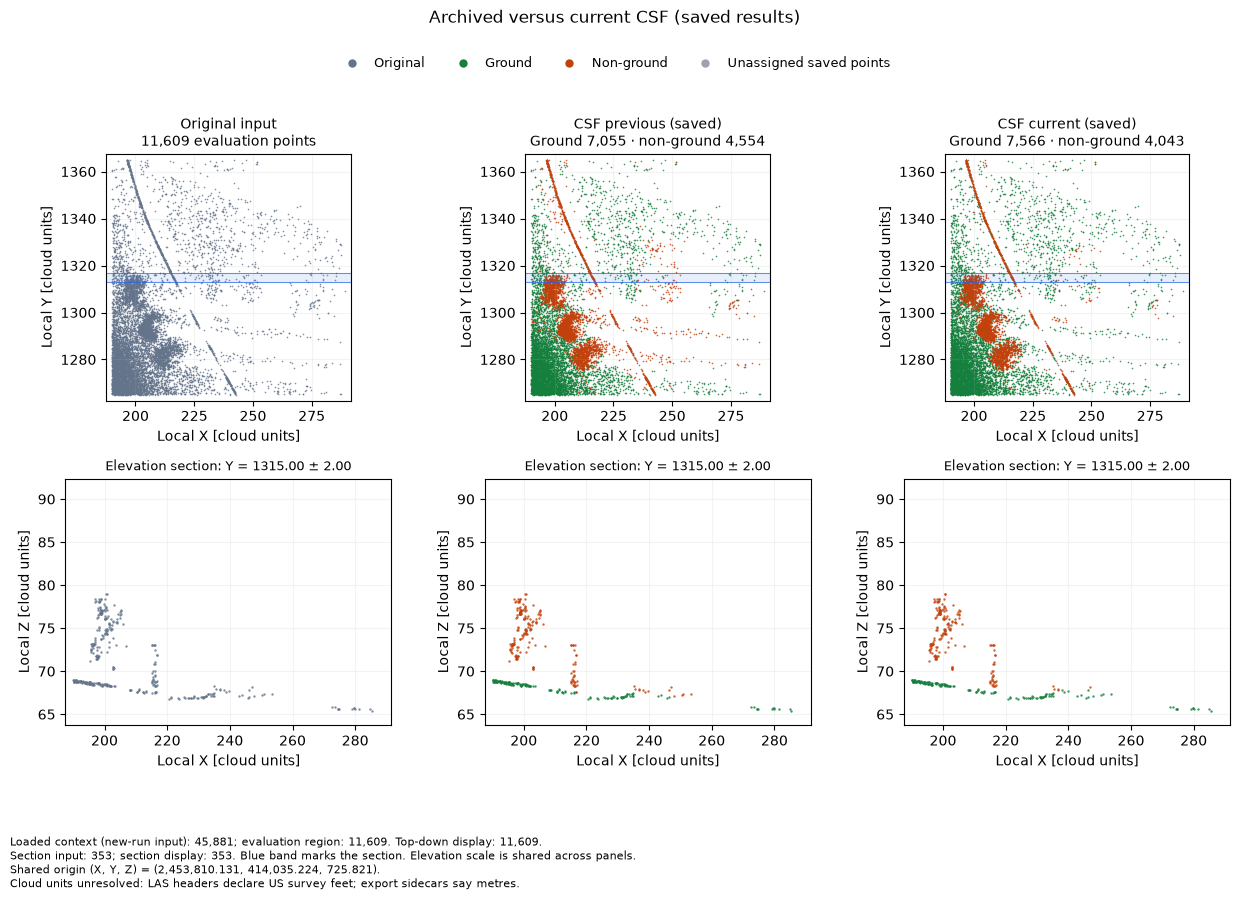

In [10]:
archived = data.load_saved_result(catalog, region, "csf_previous")
print(archived["source_note"])
saved_results = [baseline, archived, csf]
view.show_table(data.comparison_rows(region, saved_results), columns=RESULT_COLUMNS)
view.plot_comparison(region, [archived, csf], title="Archived versus current CSF (saved results)", **VIEW)

## 7. Rotate a manageable 3D view

The 3D view uses at most 12,000 evaluation points, with the same point selection across methods. Use the dropdown to switch methods, drag to rotate, and scroll to zoom. It retains fixed coordinate ranges and class colors. Static top-down views and sections above remain available even if your notebook renderer does not display Plotly.

VS Code supports the [Plotly notebook renderer](https://plotly.com/python/renderers/). If the 3D output is blocked, trust this local notebook or rerun this cell with the selected kernel. No widgets package or separate web service is required.

In [11]:
figure_3d = view.interactive_3d(region, saved_results, max_display_points=12_000)
if figure_3d is not None:
    figure_3d.show(renderer="plotly_mimetype")

## 8. Change one parameter and compute a new local experiment

This is the first stage that can **compute new ground partitions**. It processes all selected cached-sample points including the margin, then reports and plots the inner evaluation region. Baseline and CSF receive the same input records. The display cap does not affect filtering.

| Parameter | What you are changing |
|---|---|
| Baseline `cell_size` | Width of the XY cells that define each local minimum. |
| Baseline `tolerance` | Allowed height above the cell minimum. |
| CSF `cloth_resolution` | Spacing of the simulated cloth surface. |
| CSF `class_threshold` | Allowed separation from the fitted terrain surface. |
| CSF `rigidness` | How rigidly the cloth behaves; allowed values 1, 2, 3. |
| CSF `iterations`, `time_step`, `slope_smooth` | Simulation iteration limit, time step, and optional slope post-processing. |

All distance-like values below are in **unresolved source coordinate units**. The first parameter-change exercise is to change only `class_threshold`, keeping the selected points, margin, and other settings fixed. A saved whole-sample result is useful context, but compare two **fresh local runs with the same margin** to isolate a parameter change.

Enable `RUN_NEW_EXPERIMENT` deliberately. Every execution creates a new unique folder under `outputs/experiments/notebook/`. It records the context input, source identity, settings, masks, LAS partitions, core/context counts, runtime, environment, and observation text. It never calls the old script's command-line entry point or writes into the baseline folder.

In [12]:
RUN_NEW_EXPERIMENT = False  # Set True to compute a bounded local baseline + CSF run.
BASELINE_PARAMETERS = dict(cell_size=1.0, tolerance=0.35)
CSF_PARAMETERS = dict(cloth_resolution=1.0, class_threshold=0.8, rigidness=3,
                      time_step=0.65, iterations=500, slope_smooth=True)
NEW_RUN_OBSERVATION = ""  # Your observations or the question this iteration tests.

In [13]:
new_run = None
if RUN_NEW_EXPERIMENT:
    new_run = data.run_experiment(catalog, region, BASELINE_PARAMETERS, CSF_PARAMETERS,
                                  observations=NEW_RUN_OBSERVATION, display_settings=VIEW)
    print("Saved new run:", new_run["run_dir"])
else:
    print("New filtering is OFF. The figures above come from saved workspace outputs.")

New filtering is OFF. The figures above come from saved workspace outputs.


In [14]:
if new_run is not None:
    view.show_table(data.comparison_rows(region, new_run["results"]), columns=RESULT_COLUMNS)
    view.plot_comparison(region, new_run["results"], title="New local run: original, baseline, CSF", **VIEW)
else:
    print("Enable and run the experiment cell to see newly computed results here.")

Enable and run the experiment cell to see newly computed results here.


### Reopen an earlier local run and compare parameter changes

To compare new iterations fairly, copy a previous run folder printed above or listed in the history table into `PREVIOUS_RUN_DIR`. The selected side, evaluation region, margin, and input records must match; the loader rejects incompatible runs instead of comparing different samples as if they were the same.

Run once with the default local settings to create a reference, copy that folder here, then change one parameter and compute again. The next figure compares the previous local CSF result with the new local CSF result. The baseline is still saved in both runs.

In [15]:
PREVIOUS_RUN_DIR = None  # Example: PROJECT_DIR / "outputs/experiments/notebook/<run folder>"
previous_run = None
if PREVIOUS_RUN_DIR is not None:
    previous_run = data.load_notebook_run(catalog, region, PREVIOUS_RUN_DIR)
    view.show_table(data.comparison_rows(region, previous_run["results"]), columns=RESULT_COLUMNS)
    if new_run is not None:
        local_csf_pair = [next(r for r in run["results"] if r["method"] == "csf")
                          for run in [previous_run, new_run]]
        view.plot_comparison(region, local_csf_pair, title="Previous versus new local CSF", **VIEW)
else:
    print("Choose an earlier local run folder to compare new iterations visually.")

Choose an earlier local run folder to compare new iterations visually.


## 9. Record observations and compare iterations in a table

Enter what you see, including uncertainty. Useful notes identify the local coordinates or section position, whether a visible surface remains continuous, and whether unwanted elevated points remain green. Empty notes mean **not yet reviewed**, not a successful result.

The table includes inputs, settings, counts, timing and its scope, and observations. Expand structured cells to see the complete settings. Counts are for the same inner evaluation region; saved runtimes describe the historical paired pipeline, whereas fresh runtimes describe the local filters. Those timings are not comparable benchmarks.

In [16]:
OBSERVATIONS = {
    baseline["name"]: "",
    archived["name"]: "",
    csf["name"]: "",
}
# Add a local result's name and your note here; existing run notes carry forward.
review_results = list(saved_results)
for run in [previous_run, new_run]:
    if run is not None:
        review_results.extend(run["results"])
review_results = list({r["key"]: r for r in review_results}.values())
view.show_table(data.comparison_rows(region, review_results, observations=OBSERVATIONS), columns=RESULT_COLUMNS)

name,input_sample,input_points,ground_points,non_ground_points,parameters,runtime_seconds,runtime_scope,processing_context,observations
Baseline (saved),C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\run1_inputs\run1_left_sample.las,"11,609","7,890","3,719","{ ""cell_size"": 1.0, ""tolerance"": 0.35 }{ ""cell_size"": 1.0, ""tolerance"": 0.35 }",2.8842,"historical pipeline total for BOTH sides, including input/output work; not this ROI's filter time","entire historical development sample, then cropped for evaluation",
CSF previous (saved),C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\run1_inputs\run1_left_sample.las,"11,609","7,055","4,554","{ ""cloth_resolution"": 2.0, ""class_threshold"": 0.5, ""rigidness"": 2, ""time_step"": 0.65, ""…{ ""cloth_resolution"": 2.0, ""class_threshold"": 0.5, ""rigidness"": 2, ""time_step"": 0.65, ""iterations"": 200, ""slope_smooth"": false }",15.4388,"historical pipeline total for BOTH sides, including input/output work; not this ROI's filter time","entire historical development sample, then cropped for evaluation",
CSF current (saved),C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\run1_inputs\run1_left_sample.las,"11,609","7,566","4,043","{ ""cloth_resolution"": 1.0, ""class_threshold"": 0.8, ""rigidness"": 3, ""time_step"": 0.65, ""…{ ""cloth_resolution"": 1.0, ""class_threshold"": 0.8, ""rigidness"": 3, ""time_step"": 0.65, ""iterations"": 500, ""slope_smooth"": true }",142.5113,"historical pipeline total for BOTH sides, including input/output work; not this ROI's filter time","entire historical development sample, then cropped for evaluation",


### Save a review without recomputing filters

Set `SAVE_REVIEW = True` after entering your notes and run this cell. A new review folder stores a CSV comparison table and a JSON record of the region, display settings, sources, parameters, and observations. The original experiment manifests are kept intact. Fresh runs already contain a comparison record; reviews let you add observations later without rerunning CSF.

In [17]:
SAVE_REVIEW = False
if SAVE_REVIEW:
    review = data.save_review(catalog, region, review_results, OBSERVATIONS, display_settings=VIEW)
    print("Saved review:", review["run_dir"])
else:
    print("Review saving is OFF. Edit your notes above, then enable this cell to record them.")

Review saving is OFF. Edit your notes above, then enable this cell to record them.


In [18]:
history = data.history_rows(catalog)
view.show_table(history, columns=["snapshot_id", "snapshot_kind", *RESULT_COLUMNS])

snapshot_id,snapshot_kind,name,input_sample,input_points,ground_points,non_ground_points,parameters,runtime_seconds,runtime_scope,processing_context,observations
20260911T061318_502752Z_run_7b4521de,regional_ground_experiment,Baseline local 7b4521de,C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\run1_inputs\run1_left_sample.las,"11,609","7,890","3,719","{ ""cell_size"": 1.0, ""tolerance"": 0.35 }{ ""cell_size"": 1.0, ""tolerance"": 0.35 }",0.0249,this method's filter call on this region plus padding; excludes input/output,selected region plus padding only,
20260911T061318_502752Z_run_7b4521de,regional_ground_experiment,CSF local 7b4521de,C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\run1_inputs\run1_left_sample.las,"11,609","7,460","4,149","{ ""cloth_resolution"": 1.0, ""class_threshold"": 0.8, ""rigidness"": 3, ""time_step"": 0.65, ""…{ ""cloth_resolution"": 1.0, ""class_threshold"": 0.8, ""rigidness"": 3, ""time_step"": 0.65, ""iterations"": 500, ""slope_smooth"": true }",0.0742,this method's filter call on this region plus padding; excludes input/output,selected region plus padding only,
20260911T061323_564136Z_run_e681a247,regional_ground_experiment,Baseline local e681a247,C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\run1_inputs\run1_left_sample.las,"11,609","7,890","3,719","{ ""cell_size"": 1.0, ""tolerance"": 0.35 }{ ""cell_size"": 1.0, ""tolerance"": 0.35 }",0.02,this method's filter call on this region plus padding; excludes input/output,selected region plus padding only,
20260911T061323_564136Z_run_e681a247,regional_ground_experiment,CSF local e681a247,C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\run1_inputs\run1_left_sample.las,"11,609","7,364","4,245","{ ""cloth_resolution"": 1.0, ""class_threshold"": 0.6, ""rigidness"": 3, ""time_step"": 0.65, ""…{ ""cloth_resolution"": 1.0, ""class_threshold"": 0.6, ""rigidness"": 3, ""time_step"": 0.65, ""iterations"": 500, ""slope_smooth"": true }",0.0726,this method's filter call on this region plus padding; excludes input/output,selected region plus padding only,
20260911T061324_532685Z_review_2de08ee8,ground_experiment_review,Baseline (saved),C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\run1_inputs\run1_left_sample.las,"11,609","7,890","3,719","{ ""cell_size"": 1.0, ""tolerance"": 0.35 }{ ""cell_size"": 1.0, ""tolerance"": 0.35 }",2.8842,"historical pipeline total for BOTH sides, including input/output work; not this ROI's filter time","entire historical development sample, then cropped for evaluation",
20260911T061324_532685Z_review_2de08ee8,ground_experiment_review,CSF previous (saved),C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\run1_inputs\run1_left_sample.las,"11,609","7,055","4,554","{ ""cloth_resolution"": 2.0, ""class_threshold"": 0.5, ""rigidness"": 2, ""time_step"": 0.65, ""…{ ""cloth_resolution"": 2.0, ""class_threshold"": 0.5, ""rigidness"": 2, ""time_step"": 0.65, ""iterations"": 200, ""slope_smooth"": false }",15.4388,"historical pipeline total for BOTH sides, including input/output work; not this ROI's filter time","entire historical development sample, then cropped for evaluation",
20260911T061324_532685Z_review_2de08ee8,ground_experiment_review,CSF current (saved),C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\run1_inputs\run1_left_sample.las,"11,609","7,566","4,043","{ ""cloth_resolution"": 1.0, ""class_threshold"": 0.8, ""rigidness"": 3, ""time_step"": 0.65, ""…{ ""cloth_resolution"": 1.0, ""class_threshold"": 0.8, ""rigidness"": 3, ""time_step"": 0.65, ""iterations"": 500, ""slope_smooth"": true }",142.5113,"historical pipeline total for BOTH sides, including input/output work; not this ROI's filter time","entire historical development sample, then cropped for evaluation",
20260911T061324_532685Z_review_2de08ee8,ground_experiment_review,Baseline local 7b4521de,C:\Users\m3x1c\Desktop\Fall 2026\2026 Fall Hackathon\outputs\run1_inputs\run1_left_sample.la

## Your first parameter-change experiment

1. Choose the `.venv-ground` kernel and run through the saved comparisons.
2. Use the overview to select your area; position the elevation section through the feature of interest.
3. Keep the region and margin fixed. Enable `RUN_NEW_EXPERIMENT` and run the parameter, compute, and new-results cells once to create a local reference.
4. Copy its folder into `PREVIOUS_RUN_DIR`. Change only `CSF_PARAMETERS["class_threshold"]` (for example from `0.8` to `0.6`) in the parameter cell, then rerun the parameter, compute, and comparison cells.
5. Record what changed in `OBSERVATIONS` and save a review. Judge both retained ground candidates and rejected points; do not use total ground count as an accuracy score.

If you change the region, restart from the selection stage. To investigate whether sparse input caused a missing feature, a later experiment can compare denser data within the same bounded region. This notebook deliberately keeps that question separate from display sampling and does not scan the full raw clouds.

The history table also includes two execution-check runs on this real example region (thresholds 0.8 and 0.6) and their review snapshot. Their observation fields are blank: these runs verify the notebook workflow, not road accuracy. You can reopen those folders using the previous-run cell.